In [4]:
#Cell 1: Set up

# Automatically reload preprocess.py whenever it's edited, so changes show up without restarting the kernel.
%load_ext autoreload
%autoreload 2

# Add the repo's top-level folder to Python's search path so the notebook can import from scripts/.
import sys
sys.path.append("..")

# Import plotting, table-handling, and our preprocessing functions (shortened to pp).
import matplotlib.pyplot as plt
import pandas as pd
from scripts import preprocess as pp

# Sanity check: confirm the raw image folder exists and count the images in it (should be True 3662).
print(pp.RAW_IMAGE_DIR.exists(), len(list(pp.RAW_IMAGE_DIR.glob("*.png"))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
True 3662


In [11]:
#Cell 2: Choosing test images

# Load the Kaggle label file, which lists each image's ID and its DR severity grade (0-4).
labels = pd.read_csv(pp.RAW_DIR / "train.csv")

# Randomly pick 2 images from each severity grade (fixed seed for reproducibility) so testing covers all classes.
sample = labels.groupby("diagnosis").sample(2, random_state=0)

# Build the full file path for each sampled image from its ID.
paths = [pp.RAW_IMAGE_DIR / f"{i}.png" for i in sample["id_code"]]

# Display the sampled images' IDs and grades.
sample

,id_code,diagnosis
3496,f3a4751af42e,0
1552,6d10709053ae,0
1765,7ccb267fd394,1
2912,ca6842bfcbc9,1
3074,d6228d951958,2
3490,f30f203ef51e,2
3053,d3e884109b45,3
1910,86d6808f0609,3
2696,ba4d2c4b3039,4
1384,612f2df37a1d,4


(1050, 1050, 3) uint8


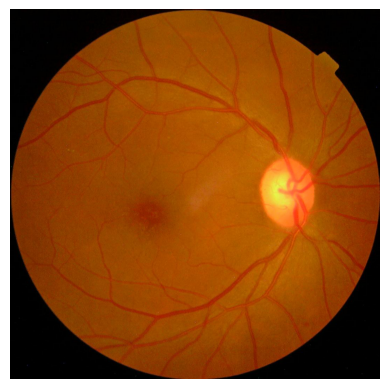

In [14]:
#Cell 3: testing load_image function

# Load the first sample image, print its dimensions and data type, and display it to check the colors are correct.
img = pp.load_image(paths[0])
print(img.shape, img.dtype)
plt.imshow(img); plt.axis("off"); plt.show()

(1050, 1050, 3) -> (1050, 1050, 3)


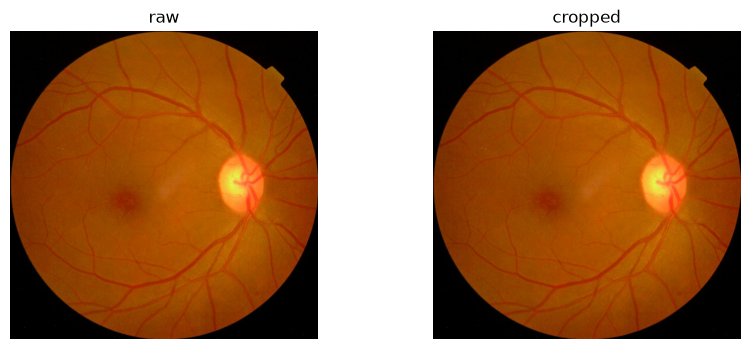

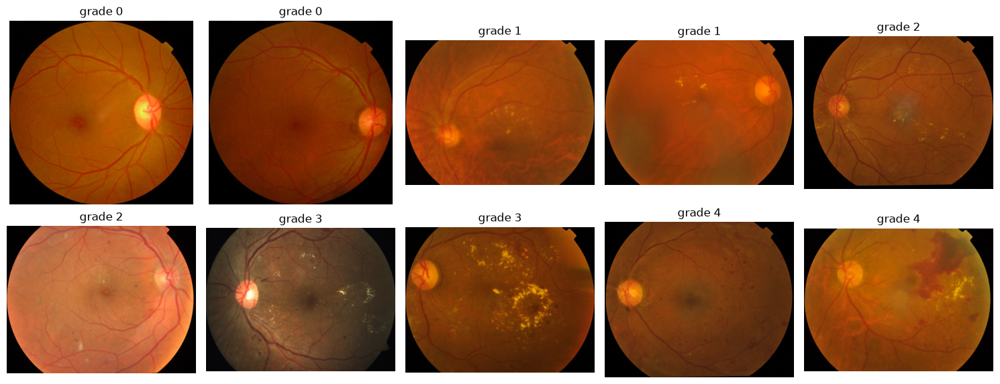

In [15]:
#Cell 4: testing crop_to_retina function

# Crop the black border from the sample image and show the raw and cropped versions side by side.
cropped = pp.crop_to_retina(img)
print(img.shape, "->", cropped.shape)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img); ax[0].set_title("raw")
ax[1].imshow(cropped); ax[1].set_title("cropped")
for a in ax: a.axis("off")
plt.show()

# Crop all 10 sample images and show them in a grid to check the crop works across different images.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path, grade in zip(axes.flat, paths, sample["diagnosis"]):
    ax.imshow(pp.crop_to_retina(pp.load_image(path)))
    ax.set_title(f"grade {grade}"); ax.axis("off")
plt.tight_layout(); plt.show()

(224, 224, 3)


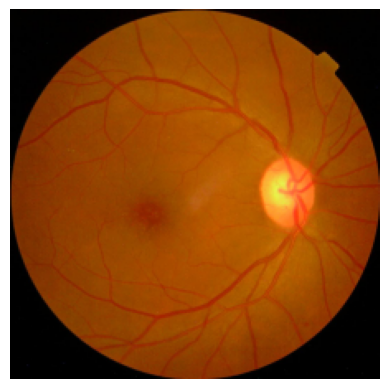

In [16]:
#Cell 5: testing resize_image function

# Resize the cropped image to 224x224 and confirm the new shape.
small = pp.resize_image(cropped)
print(small.shape)
plt.imshow(small); plt.axis("off"); plt.show()

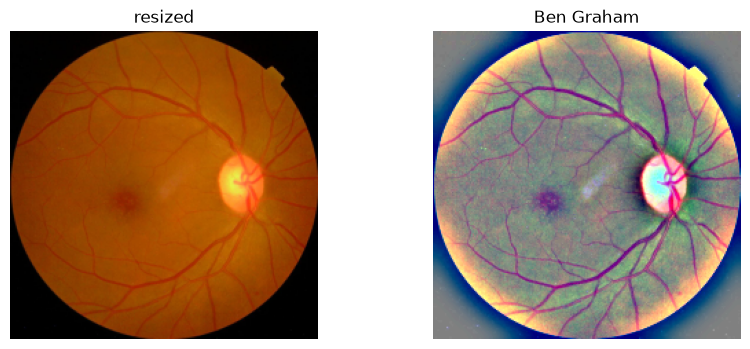

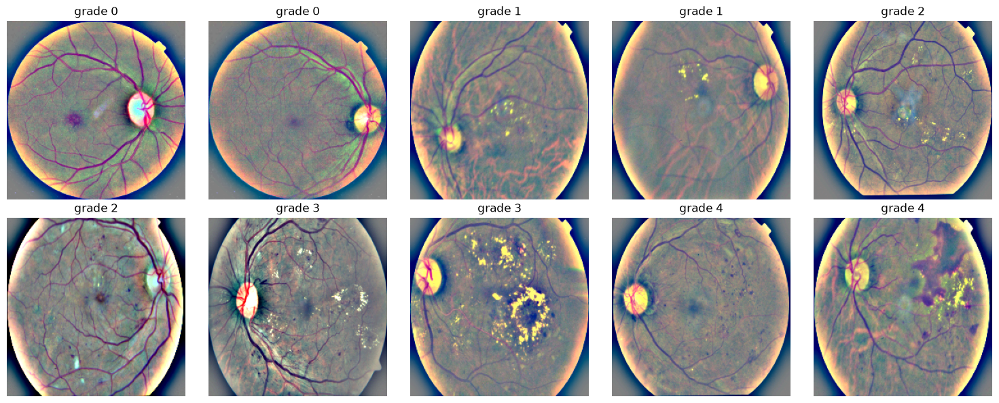

In [20]:
#Cell 6: testing ben_graham function

# Apply the Ben Graham enhancement and compare it to the resized image.
enhanced = pp.ben_graham(small)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(small); ax[0].set_title("resized")
ax[1].imshow(enhanced); ax[1].set_title("Ben Graham")
for a in ax: a.axis("off")
plt.show()

# Show the Ben Graham result for all 10 samples to judge whether the blur strength looks right.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path, grade in zip(axes.flat, paths, sample["diagnosis"]):
    ax.imshow(pp.ben_graham(pp.resize_image(pp.crop_to_retina(pp.load_image(path)))))
    ax.set_title(f"grade {grade}"); ax.axis("off")
plt.tight_layout(); plt.show()

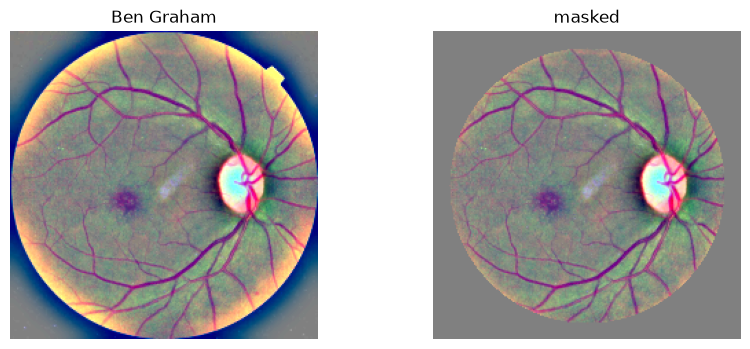

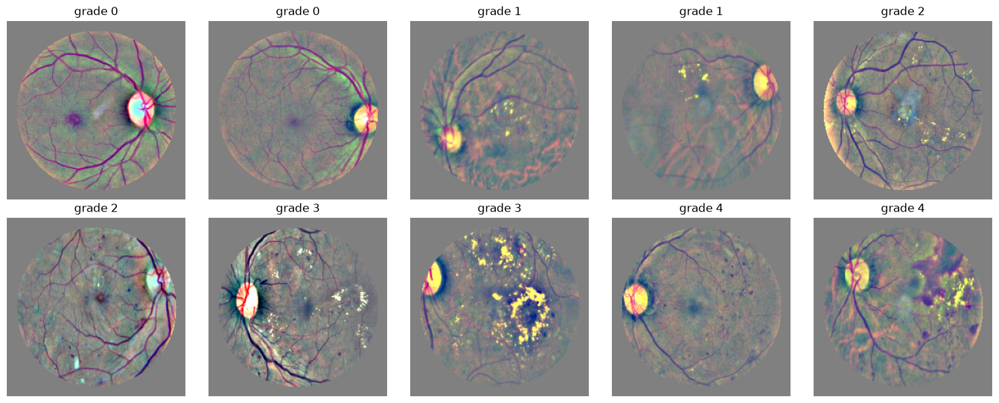

In [23]:
#Cell 7: apply_circular_mask

# Apply the circular mask and compare it to the unmasked Ben Graham image.
masked = pp.apply_circular_mask(enhanced)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(enhanced); ax[0].set_title("Ben Graham")
ax[1].imshow(masked); ax[1].set_title("masked")
for a in ax: a.axis("off")
plt.show()

# Show the full enhanced-and-masked result for all 10 samples.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path, grade in zip(axes.flat, paths, sample["diagnosis"]):
    img_bg = pp.ben_graham(pp.resize_image(pp.crop_to_retina(pp.load_image(path))))
    ax.imshow(pp.apply_circular_mask(img_bg))
    ax.set_title(f"grade {grade}"); ax.axis("off")
plt.tight_layout(); plt.show()

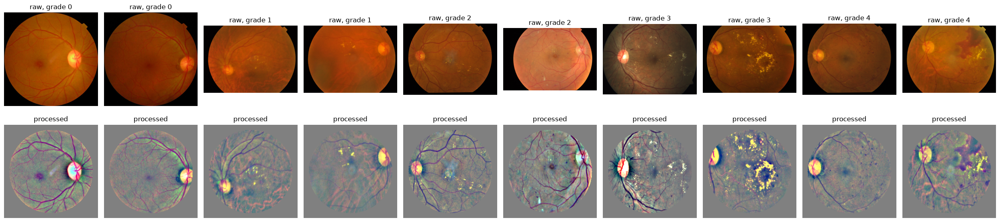

(224, 224, 3) uint8 0 255


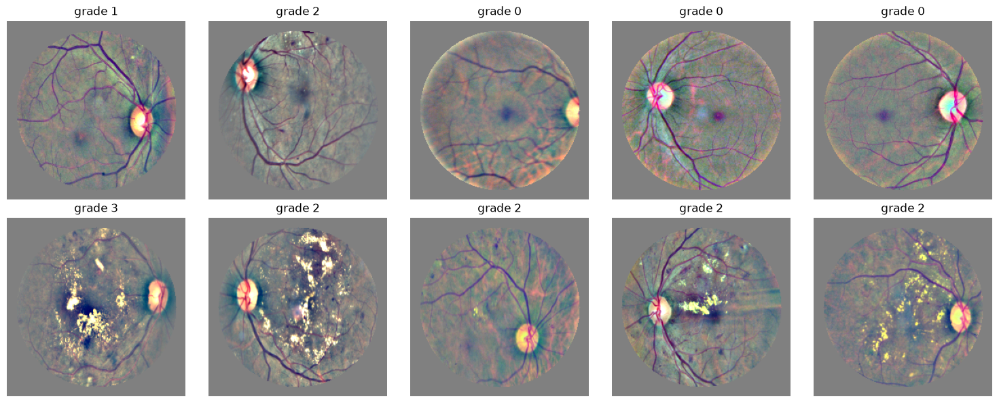

In [28]:
#Cell 8: Full preprocess pipeline

# Run the full pipeline on all 10 samples and show raw vs. processed for each.
fig, axes = plt.subplots(2, 10, figsize=(25, 6))
for i, (path, grade) in enumerate(zip(paths, sample["diagnosis"])):
    axes[0, i].imshow(pp.load_image(path)); axes[0, i].set_title(f"raw, grade {grade}")
    axes[1, i].imshow(pp.preprocess_image(path)); axes[1, i].set_title("processed")
for a in axes.flat: a.axis("off")
plt.tight_layout(); plt.show()

# Verify the final output has the shape and data type the next stage expects.
out = pp.preprocess_image(paths[0])
print(out.shape, out.dtype, out.min(), out.max())

# Run the pipeline on 10 new random images to make sure the settings work beyond the tuning set.
extra = labels.sample(10, random_state=1)
extra_paths = [pp.RAW_IMAGE_DIR / f"{i}.png" for i in extra["id_code"]]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path, grade in zip(axes.flat, extra_paths, extra["diagnosis"]):
    ax.imshow(pp.preprocess_image(path))
    ax.set_title(f"grade {grade}"); ax.axis("off")
plt.tight_layout(); plt.show()

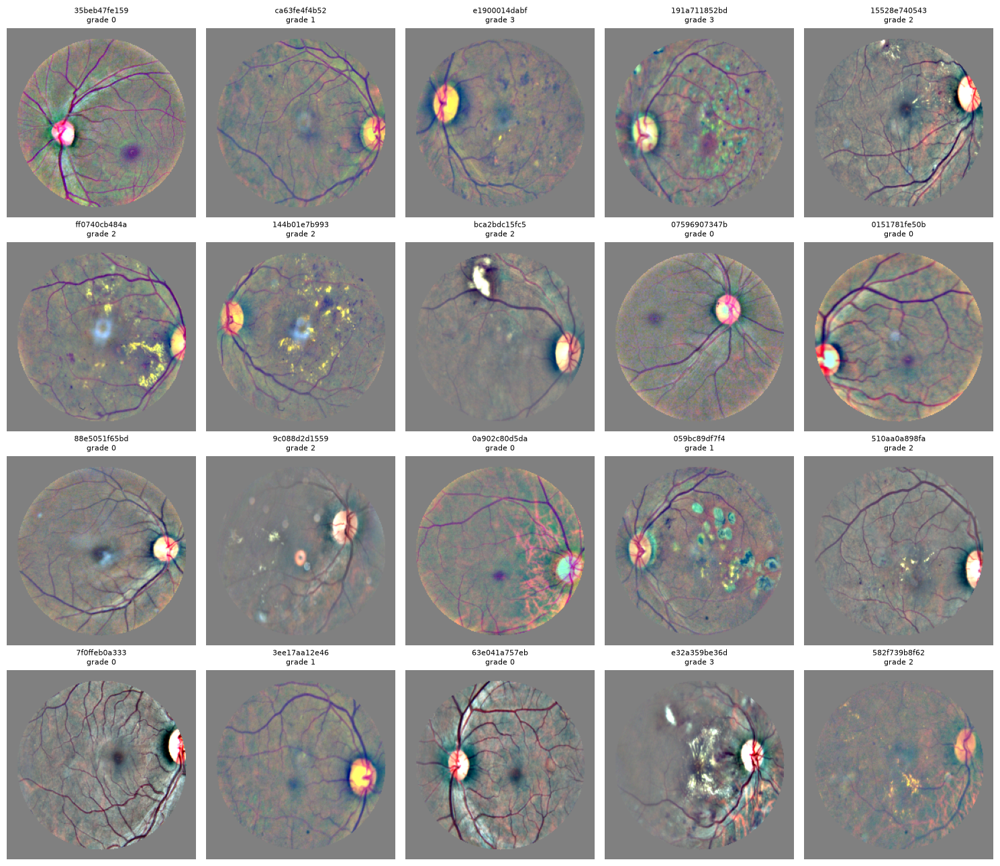

In [34]:
# Final check: run the pipeline on 20 new random images to catch any remaining problem cases.
final_check = labels.sample(20, random_state=2)
fig, axes = plt.subplots(4, 5, figsize=(15, 13))
for ax, img_id, grade in zip(axes.flat, final_check["id_code"], final_check["diagnosis"]):
    ax.imshow(pp.preprocess_image(pp.RAW_IMAGE_DIR / f"{img_id}.png"))
    ax.set_title(f"{img_id}\ngrade {grade}", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

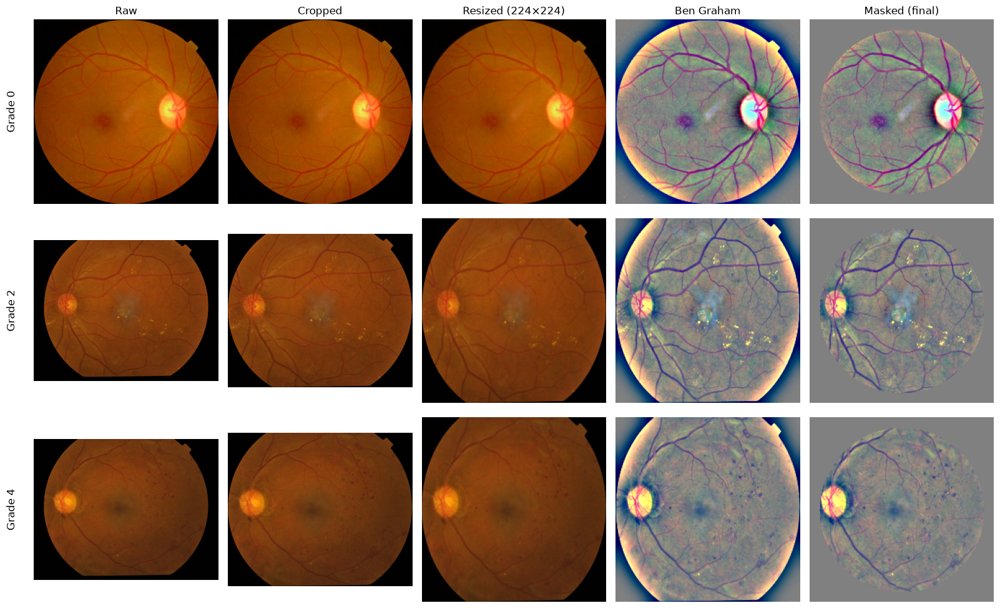

In [35]:
# Build a report figure showing each preprocessing stage for three images of increasing DR severity.
from pathlib import Path

fig_ids = sample["id_code"].iloc[[0, 4, 8]]   # one each from grades 0, 2, and 4
fig_grades = sample["diagnosis"].iloc[[0, 4, 8]]
stages = ["Raw", "Cropped", "Resized (224×224)", "Ben Graham", "Masked (final)"]

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for r, (img_id, grade) in enumerate(zip(fig_ids, fig_grades)):
    raw = pp.load_image(pp.RAW_IMAGE_DIR / f"{img_id}.png")
    c = pp.crop_to_retina(raw)
    s = pp.resize_image(c)
    b = pp.ben_graham(s)
    m = pp.apply_circular_mask(b)
    for col, im in enumerate([raw, c, s, b, m]):
        axes[r, col].imshow(im); axes[r, col].axis("off")
        if r == 0:
            axes[r, col].set_title(stages[col], fontsize=12)
    axes[r, 0].text(-0.15, 0.5, f"Grade {grade}", transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=12)
plt.tight_layout()

# Save the figure to reports/figures/, creating the folder if it doesn't exist.
out_dir = Path("../reports/figures")
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "preprocessing_steps.png", dpi=200, bbox_inches="tight")
plt.show()